# Description:

In this project, you will work with a dataset containing information about retail sales. The goal is
to perform exploratory data analysis (EDA) to uncover patterns, trends, and insights that can
help the retail business make informed decisions.

## Data Loading and Cleaning: Load the retail sales dataset

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [90]:
data = pd.read_csv("retail_sales_dataset.csv")

In [91]:
data.sample(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
180,181,2023-11-03,CUST181,Male,19,Electronics,4,300,1200
347,348,2023-12-03,CUST348,Female,35,Electronics,2,300,600
319,320,2023-02-01,CUST320,Female,28,Electronics,4,300,1200
636,637,2023-09-01,CUST637,Male,43,Clothing,2,300,600
101,102,2023-04-28,CUST102,Female,47,Beauty,2,25,50
544,545,2023-06-01,CUST545,Male,27,Clothing,2,25,50
240,241,2023-09-21,CUST241,Female,23,Electronics,3,25,75
161,162,2023-08-21,CUST162,Male,39,Clothing,2,30,60
787,788,2023-06-27,CUST788,Female,52,Beauty,3,300,900
33,34,2023-12-24,CUST034,Female,51,Clothing,3,50,150


In [92]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 100.2 KB


In [93]:
data[["Age", "Quantity", "Price per Unit", "Total Amount"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1000.0,41.392,13.681430,18.0,29.0,42.0,53.0,64.0
Quantity,1000.0,2.514,1.132734,1.0,1.0,3.0,4.0,4.0
Price per Unit,1000.0,179.890,189.681356,25.0,30.0,50.0,300.0,500.0
Total Amount,1000.0,456.000,559.997632,25.0,60.0,135.0,900.0,2000.0


In [94]:
# to know if fount any value not real

for col in data.columns.to_list():
    print(data[col].value_counts())
    print("=" * 30)

Transaction ID
1       1
2       1
3       1
4       1
5       1
       ..
996     1
997     1
998     1
999     1
1000    1
Name: count, Length: 1000, dtype: int64
Date
2023-05-16    11
2023-07-14    10
2023-05-23     9
2023-08-05     8
2023-02-05     8
              ..
2023-03-02     1
2023-08-02     1
2023-04-17     1
2023-03-30     1
2023-05-28     1
Name: count, Length: 345, dtype: int64
Customer ID
CUST001     1
CUST002     1
CUST003     1
CUST004     1
CUST005     1
           ..
CUST996     1
CUST997     1
CUST998     1
CUST999     1
CUST1000    1
Name: count, Length: 1000, dtype: int64
Gender
Female    510
Male      490
Name: count, dtype: int64
Age
64    31
43    31
51    30
57    30
34    28
54    28
22    27
62    27
42    26
47    26
46    25
23    24
40    24
50    23
27    23
26    22
30    22
52    22
35    22
31    22
60    22
19    21
18    21
28    21
55    21
20    21
41    21
21    20
25    20
49    19
38    19
56    19
32    19
39    18
48    18
61    18
45    17


In [95]:
data["Transaction ID"] = data["Transaction ID"].astype("str")

In [96]:
data["Date"] = pd.to_datetime(data["Date"], format="%Y-%m-%d", errors="coerce")

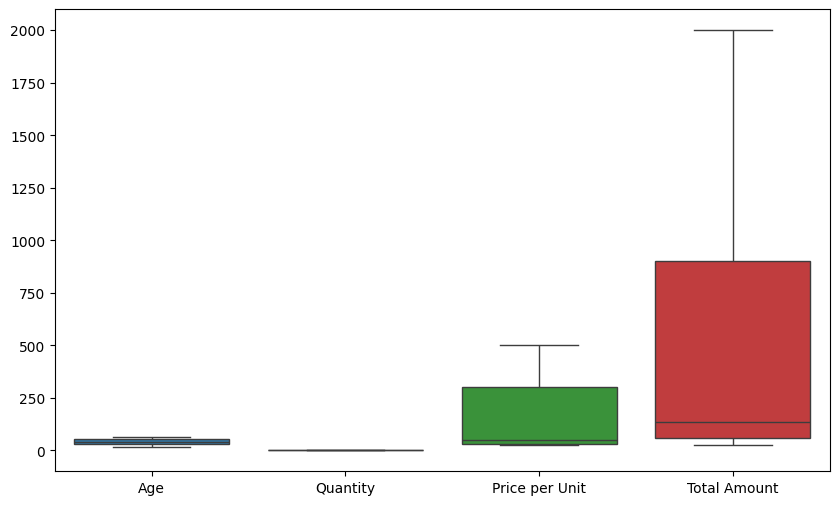

In [97]:
# show outlier in each numeric variable 
outlier = data[["Age", "Quantity", "Price per Unit", "Total Amount"]]

plt.figure(figsize=(10,6))
sns.boxplot(outlier)
plt.show()

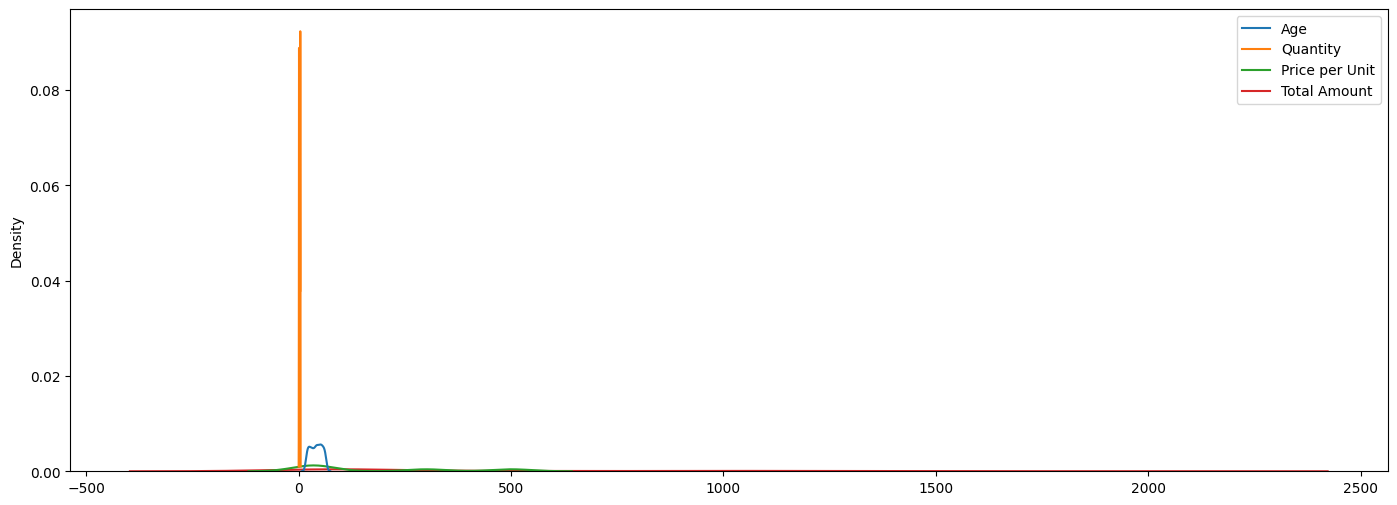

In [98]:
plt.figure(figsize=(17,6))
sns.kdeplot(outlier)
plt.show()

## Descriptive Statistics: Calculate basic statistics (mean, median, mode, standard deviation)

In [99]:
data[["Age", "Quantity", "Price per Unit", "Total Amount"]].mean()

Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

In [100]:
data[["Age", "Quantity", "Price per Unit", "Total Amount"]].median()

Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

In [101]:
data[["Age", "Quantity", "Price per Unit", "Total Amount"]].mode()

,Age,Quantity,Price per Unit,Total Amount
0,43,4.0,50.0,50.0
1,64,NaN,NaN,NaN


In [102]:
data[["Age", "Quantity", "Price per Unit", "Total Amount"]].std()

Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64

In [103]:
data[["Age", "Quantity", "Price per Unit", "Total Amount"]].var()

Age                  187.181518
Quantity               1.283087
Price per Unit     35979.016917
Total Amount      313597.347347
dtype: float64

## Time Series Analysis: Analyze sales trends over time using time series techniques.



In [104]:
data.set_index("Date", inplace=True)

In [105]:
data.head()

,Transaction ID,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
Date,,,,,,,,
2023-11-24,1,CUST001,Male,34,Beauty,3,50,150
2023-02-27,2,CUST002,Female,26,Clothing,2,500,1000
2023-01-13,3,CUST003,Male,50,Electronics,1,30,30
2023-05-21,4,CUST004,Male,37,Clothing,1,500,500
2023-05-06,5,CUST005,Male,30,Beauty,2,50,100


In [106]:
data.rename(columns={"Total Amount": "Sales"}, inplace = True)

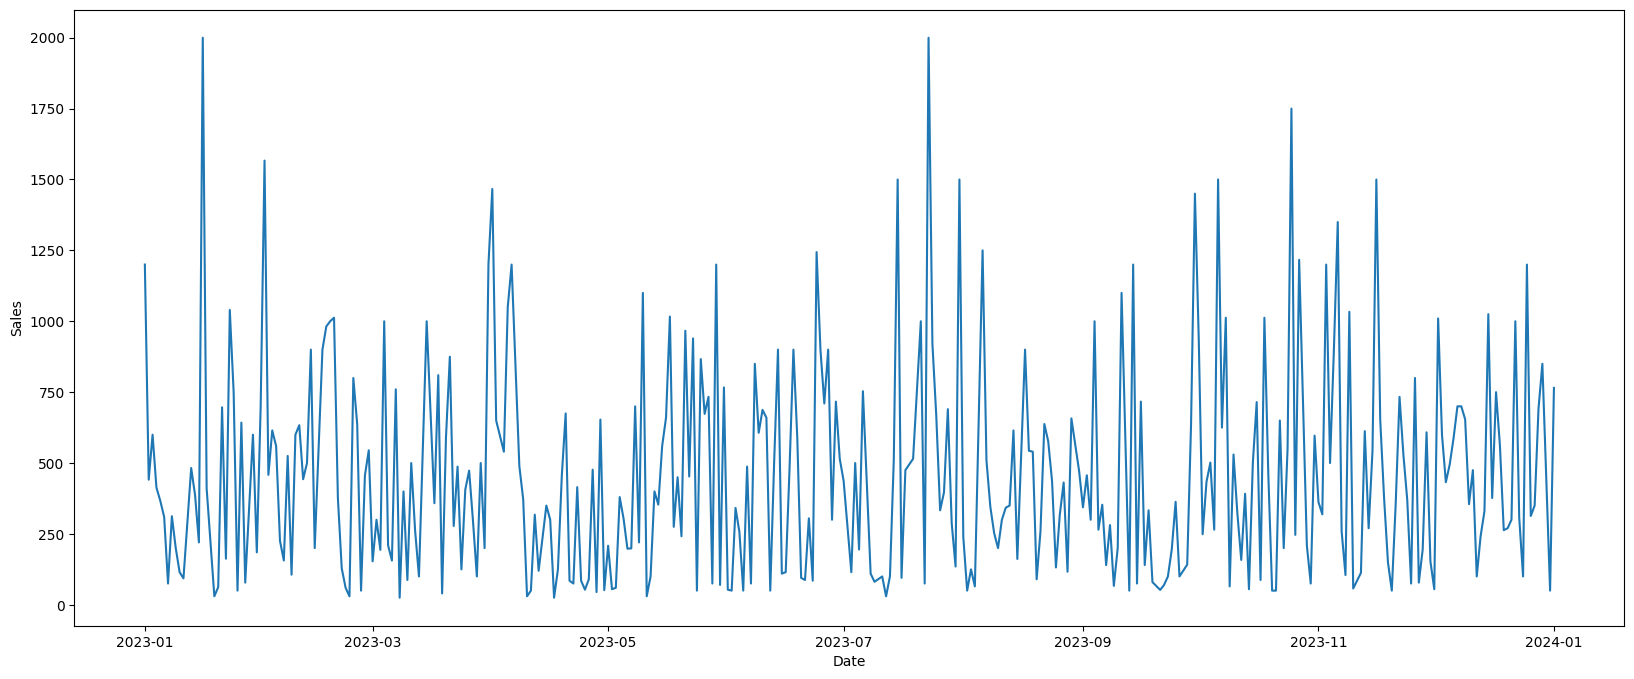

In [107]:
plt.figure(figsize=(20, 8))
sns.lineplot(data = data, x = "Date", y = 'Sales', errorbar=None)
plt.show()

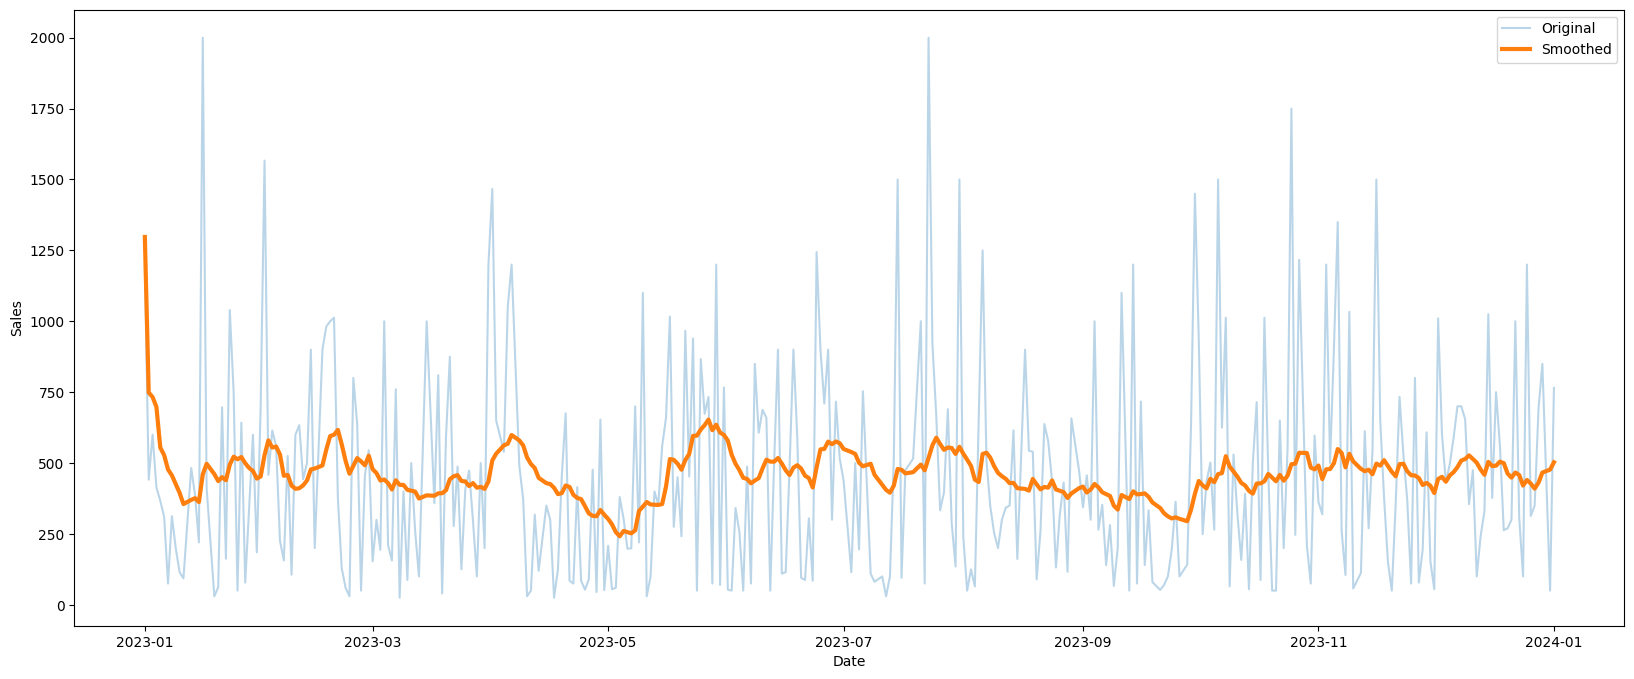

In [108]:
data = data.sort_index()

data["Sales_Smoothed"] = data["Sales"].ewm(span=60).mean()

plt.figure(figsize=(20, 8))

sns.lineplot(x=data.index, y=data["Sales"], errorbar=None, alpha=0.3, label="Original")
sns.lineplot(x=data.index, y=data["Sales_Smoothed"], errorbar=None, linewidth=3, label="Smoothed")

plt.show()

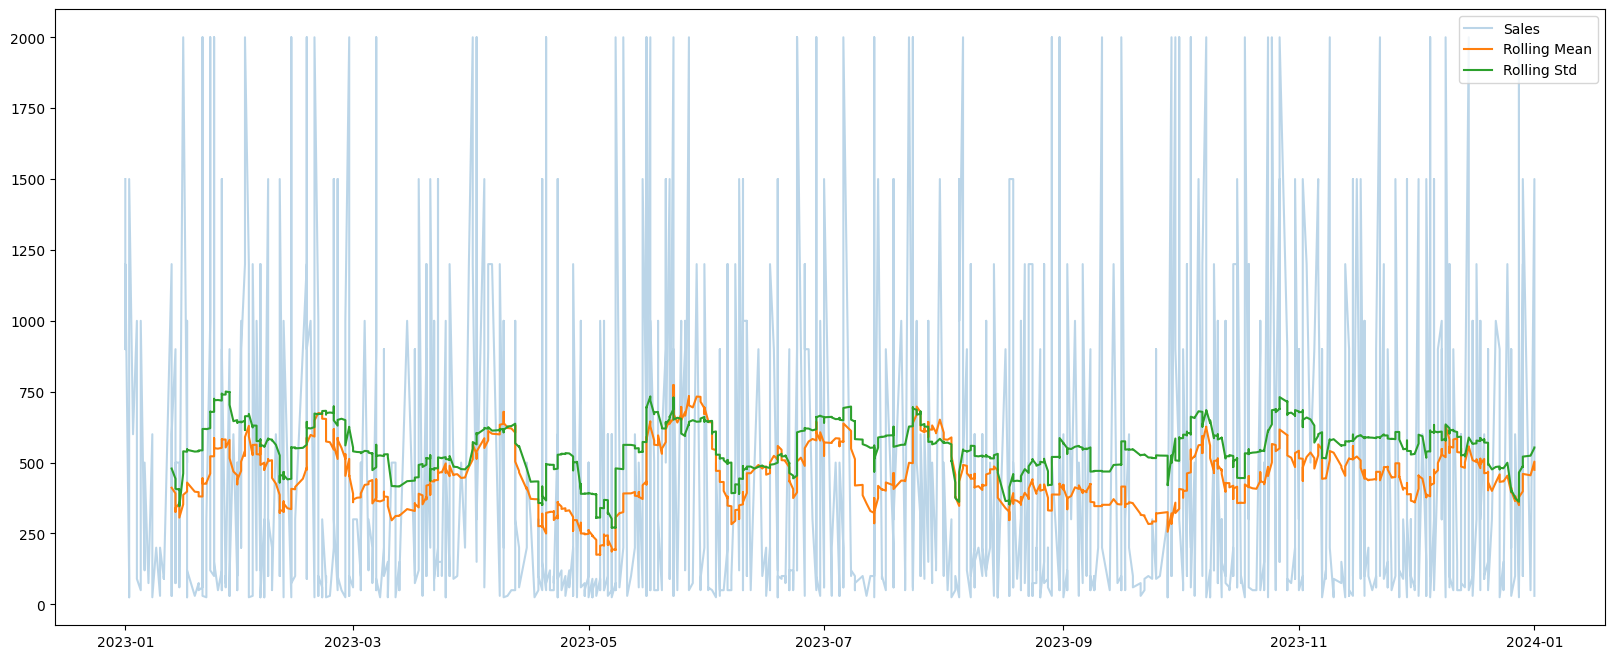

In [109]:
data["Rolling_Mean"] = data["Sales"].rolling(window=30).mean()
data["Rolling_Std"] = data["Sales"].rolling(window=30).std()

plt.figure(figsize=(20,8))
plt.plot(data.index, data["Sales"], label="Sales", alpha=0.3)
plt.plot(data.index, data["Rolling_Mean"], label="Rolling Mean")
plt.plot(data.index, data["Rolling_Std"], label="Rolling Std")
plt.legend()
plt.show()

In [111]:
data.head()

,Transaction ID,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Sales,Sales_Smoothed,Rolling_Mean,Rolling_Std
Date,,,,,,,,,,,
2023-01-01,522,CUST522,Male,46,Beauty,3,500,1500,1500.000000,NaN,NaN
2023-01-01,180,CUST180,Male,41,Clothing,3,300,900,1195.000000,NaN,NaN
2023-01-01,559,CUST559,Female,40,Clothing,4,300,1200,1196.722526,NaN,NaN
2023-01-02,303,CUST303,Male,19,Electronics,3,30,90,906.056755,NaN,NaN
2023-01-02,979,CUST979,Female,19,Beauty,1,25,25,717.905550,NaN,NaN


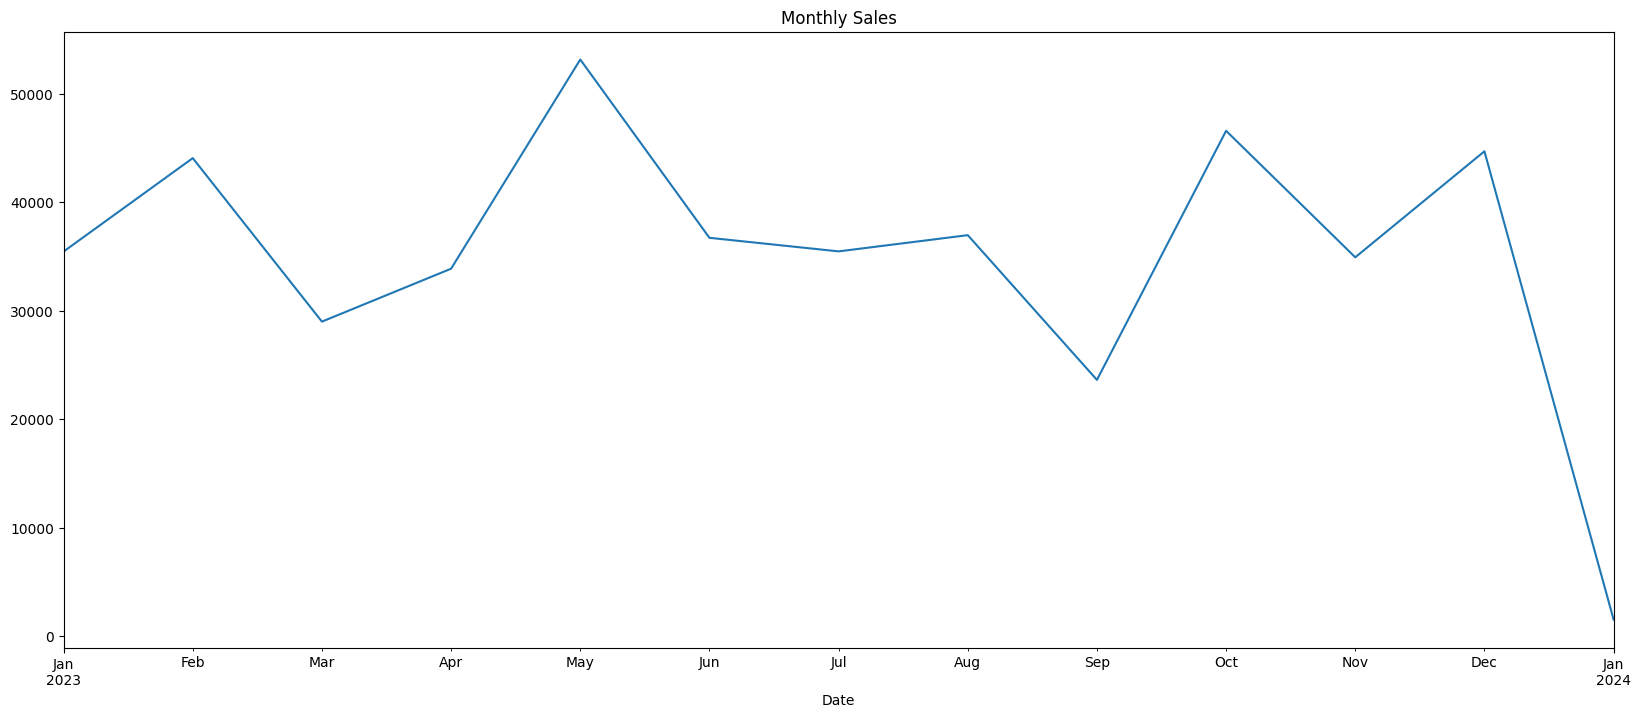

In [112]:
monthly_sales = data["Sales"].resample("ME").sum()

plt.figure(figsize=(20,8))
monthly_sales.plot()
plt.title("Monthly Sales")
plt.show()

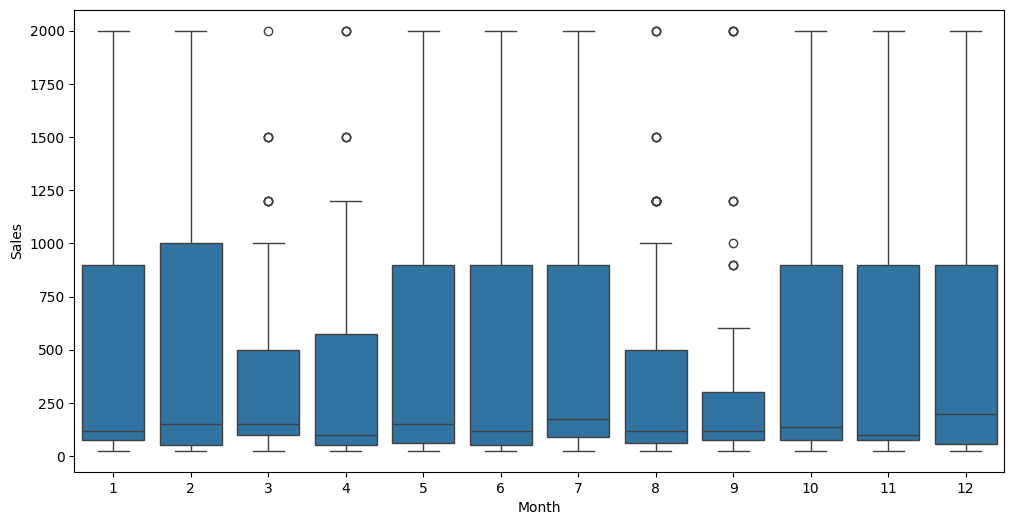

In [113]:
temp = data.copy()
temp["Month"] = temp.index.month

plt.figure(figsize=(12,6))
sns.boxplot(data=temp, x="Month", y="Sales")
plt.show()

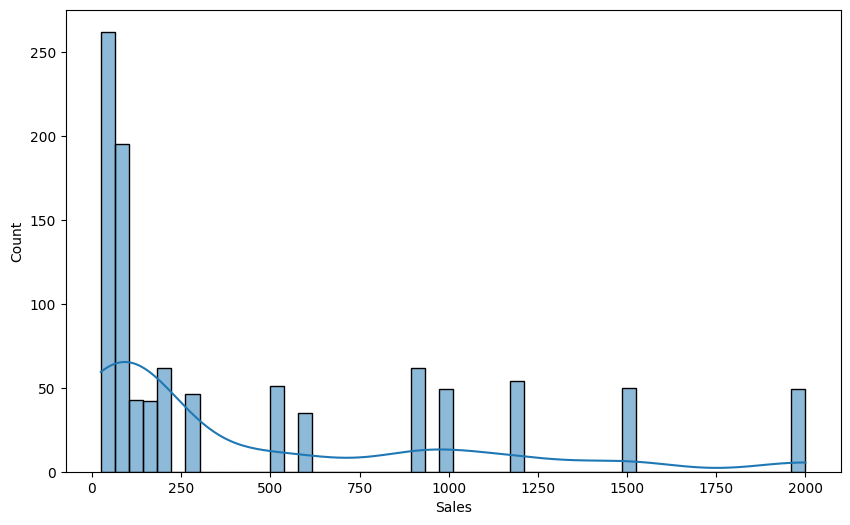

In [114]:
plt.figure(figsize=(10,6))
sns.histplot(data["Sales"], bins=50, kde=True)
plt.show()

## Customer and Product Analysis: Analyze customer demographics and purchasing behavior.



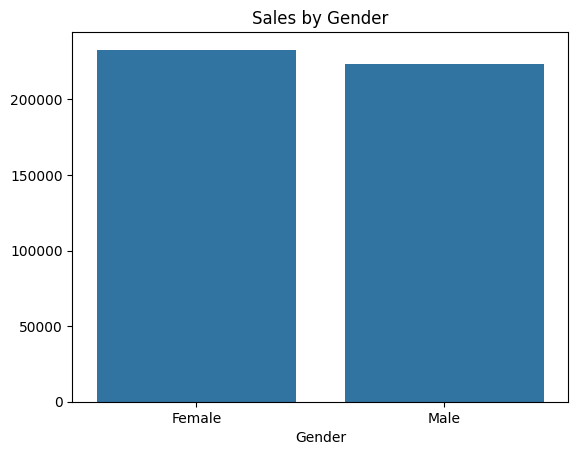

In [116]:
sns.barplot(
    x=data.groupby("Gender")["Sales"].sum().index,
    y=data.groupby("Gender")["Sales"].sum().values
)
plt.title("Sales by Gender")
plt.show()

In [117]:
bins = [0, 18, 25, 35, 45, 60, 100]
labels = ["0-18", "19-25", "26-35", "36-45", "46-60", "60+"]

data["Age Group"] = pd.cut(data["Age"], bins=bins, labels=labels)

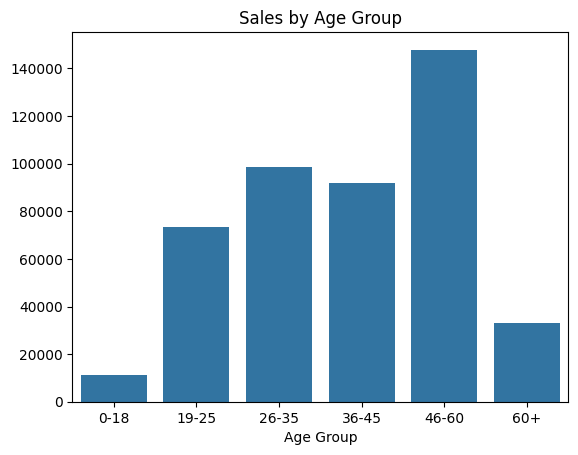

In [118]:
age_sales = data.groupby("Age Group")["Sales"].sum()

sns.barplot(x=age_sales.index, y=age_sales.values)
plt.title("Sales by Age Group")
plt.show()

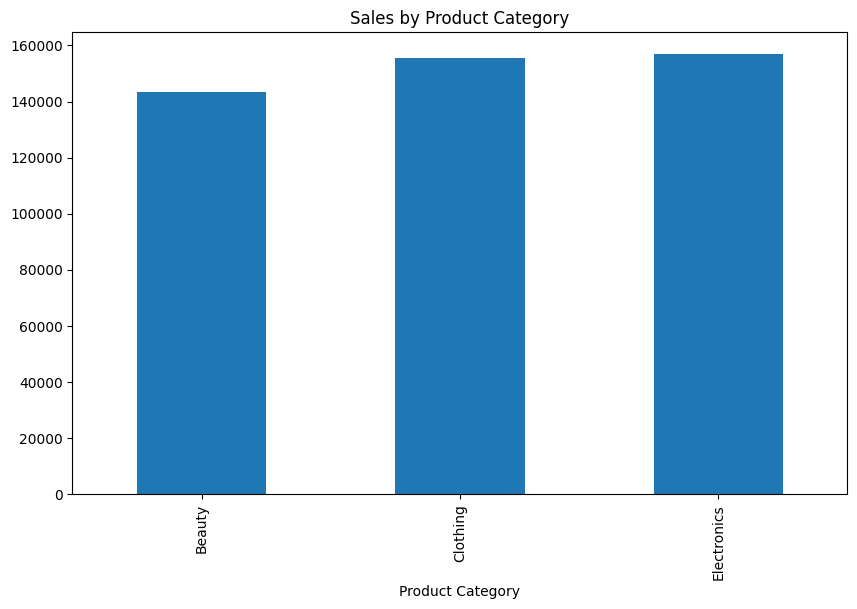

In [120]:
category_sales = data.groupby("Product Category")["Sales"].sum()

category_sales.plot(kind="bar", figsize=(10,6))
plt.title("Sales by Product Category")
plt.show()

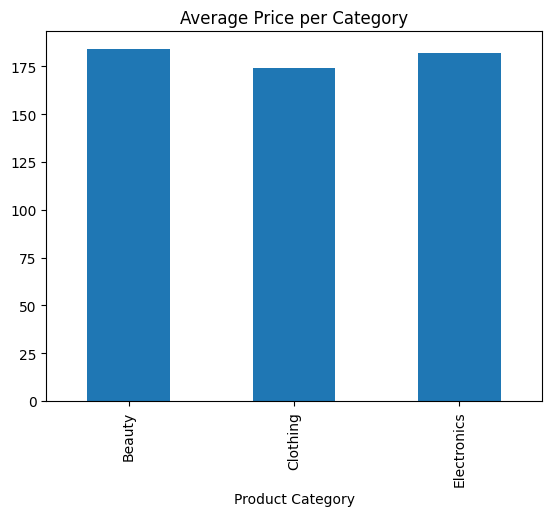

In [124]:
avg_price = data.groupby("Product Category")["Price per Unit"].mean()

avg_price.plot(kind="bar")
plt.title("Average Price per Category")
plt.show()

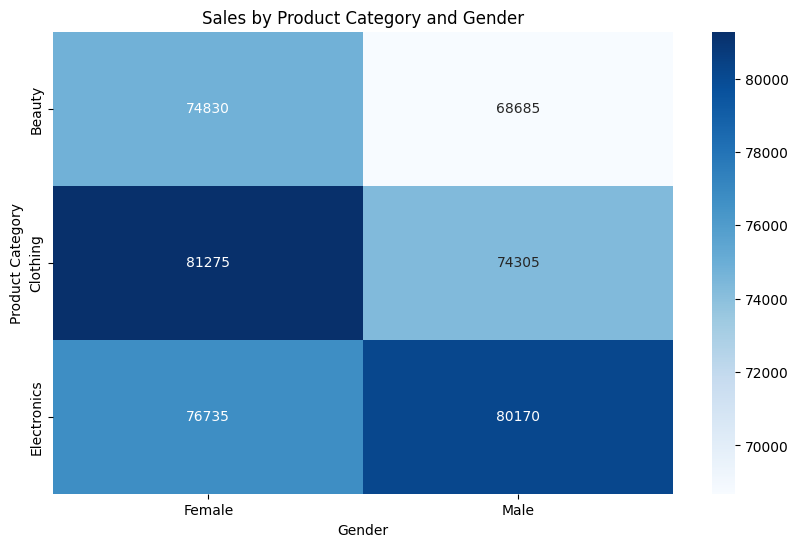

In [125]:
pivot = data.pivot_table(
    index="Product Category",
    columns="Gender",
    values="Sales",
    aggfunc="sum"
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Blues")

plt.title("Sales by Product Category and Gender")
plt.show()

## Recommendations: Provide actionable recommendations based on the EDA.





## 1. Focus More on Electronics and Clothing Categories

Electronics and Clothing generated the highest sales compared to Beauty products. The company should increase marketing efforts and inventory availability for these categories to maximize revenue.

---

## 2. Improve Marketing for Beauty Products

Beauty products showed the lowest overall sales. Special promotions, discounts, or bundled offers could help increase customer interest and improve sales performance.

---

## 3. Target Customers Aged 46–60

Customers aged 46–60 contributed the highest sales among all age groups. The business should design targeted campaigns and personalized offers for this segment since they represent the most valuable customers.

---

## 4. Increase Engagement with Younger Customers

Customers aged 0–18 and 19–25 generated lower sales. The company could attract younger audiences through:
- Student discounts
- Social media campaigns
- Influencer marketing
- Lower-priced product options

---

## 5. Maintain Balanced Gender Marketing

Sales between male and female customers were relatively balanced, with females contributing slightly higher revenue. Marketing strategies should continue targeting both genders while slightly emphasizing female-focused campaigns.

---

## 6. Seasonal Sales Opportunities Should Be Utilized

Monthly sales trends showed peaks in months such as May, October, and December. The business should:
- Increase inventory before high-sales periods
- Launch seasonal campaigns during peak months
- Prepare promotional events for holidays and shopping seasons

---

## 7. Monitor Sales Volatility

The rolling statistics and smoothed time-series plots indicate fluctuations and spikes in sales over time. The company should monitor unusual spikes and identify whether they are caused by promotions, seasonal demand, or external factors.

---

## 8. Use Data-Driven Inventory Planning

Since some categories consistently perform better than others, inventory planning should prioritize high-performing products to avoid stock shortages and improve operational efficiency.

---

## 9. Develop Customer Loyalty Programs

A loyalty or rewards program could help increase repeat purchases and strengthen customer retention, especially for high-spending age groups.

---

## 10. Continue Using Time-Series Forecasting

The time-series analysis revealed changing sales patterns throughout the year. Implementing forecasting models can help predict future demand and support better business planning and budgeting.